In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor # Or XGBoost, CatBoost
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import timeit
import functools
import tqdm

# GPU Libraries
import cudf
import cupy as cp

# Optional: RMM for memory management
# import rmm
# rmm.reinitialize(pool_allocator=True)

print(f"Using cuDF {cudf.__version__}")
print(f"Using CuPy {cp.__version__}")


# Function to time cuDF filtering operations
def time_cudf_filter_operation(num_rows, num_cols, dtype, nan_ratio, target_selectivity):
    """Generates a cuDF DataFrame, applies filtering on GPU, and records wall-clock time."""
    df = None # Ensure df is defined for finally block
    data = None # Ensure data is defined
    try:
        # 1. Create data on GPU using CuPy - CORRECTED
        cupy_dtype = None # Determine actual cupy type later
        if dtype == int:
            cupy_dtype = cp.int64 # Choose desired int precision
            # Use randint for integer types
            data = cp.random.randint(0, 100, size=(num_rows, num_cols), dtype=cupy_dtype)
        elif dtype == float:
            cupy_dtype = cp.float64 # Choose desired float precision
            # Use uniform for float types in the range [0, 100)
            data = cp.random.uniform(0.0, 100.0, size=(num_rows, num_cols)).astype(cupy_dtype)
        else:
            print(f"Warning: Unsupported dtype requested: {dtype}. Skipping.")
            return None # Handle unsupported types

        # Create cuDF DataFrame
        df = cudf.DataFrame(data, columns=[f"col_{i}" for i in range(num_cols)])

        # --- Rest of the function remains the same ---

        # 2. Introduce NaNs (only if float type)
        actual_nan_ratio = 0.0
        if cp.issubdtype(cupy_dtype, cp.floating):
            nan_mask_gpu = cp.random.rand(num_rows) < nan_ratio
            df['col_0'] = df['col_0'].astype(cp.float64) # Ensure float for NaNs
            df['col_0'] = df['col_0'].mask(cudf.Series(nan_mask_gpu), cp.nan)
            actual_nan_ratio = nan_ratio
        # Else: Integer type, skip NaN introduction

        # 3. Determine threshold (on GPU)
        col_0_valid = df["col_0"].dropna()
        if len(col_0_valid) == 0:
             return None
        threshold = col_0_valid.quantile(target_selectivity, interpolation='linear')

        # 4. Setup filtering function
        filter_func = functools.partial(lambda d, t: d[d["col_0"] < t], df, threshold)

        # 5. Time the operation
        cp.cuda.runtime.deviceSynchronize()
        _ = filter_func()
        cp.cuda.runtime.deviceSynchronize()

        n_runs = 7
        exec_time_total = timeit.timeit(lambda: (filter_func(), cp.cuda.runtime.deviceSynchronize()), number=n_runs)
        exec_time_sec = exec_time_total / n_runs

        return {
            'num_rows': num_rows,
            'num_cols': num_cols,
            'dtype_str': dtype.__name__,
            'nan_ratio': actual_nan_ratio,
            # 'target_selectivity': target_selectivity,
            'exec_time_sec': exec_time_sec
        }

    except cp.cuda.memory.OutOfMemoryError:
        print(f"OOM Error: rows={num_rows}, cols={num_cols}. Skipping.")
        return None
    except Exception as e:
        # Provide more context in error message
        print(f"Error timing cuDF: rows={num_rows}, cols={num_cols}, dtype={dtype}, requested_dtype={dtype.__name__}, nan_ratio={nan_ratio}, sel={target_selectivity}. Error: {e}. Skipping.")
        # Optionally raise e # To stop execution and debug
        return None
    finally:
        del df
        del data
        mempool = cp.get_default_memory_pool()
        mempool.free_all_blocks()


# --- Data Generation Loop (No changes needed here) ---
n_samples = 5000 # Keep it smaller initially for testing
data_samples = []
print("Generating cuDF benchmark data...")
# ... (rest of your data generation loop using the corrected function) ...
for _ in tqdm.tqdm(range(n_samples)):
    # Adjust ranges based on your GPU memory!
    num_rows_sample = np.random.randint(100000, 300000) # Example range
    num_cols_sample = np.random.randint(1, 20)         # Use the random cols
    dtype_sample = np.random.choice([int, float])
    nan_ratio_sample = np.random.uniform(0, 0.5)
    selectivity_sample = np.random.uniform(0.01, 0.9)

    sample = time_cudf_filter_operation(
        num_rows=num_rows_sample,
        num_cols=num_cols_sample, # Pass num_cols
        dtype=dtype_sample,
        nan_ratio=nan_ratio_sample,
        target_selectivity=selectivity_sample
    )
    if sample: # Only append if timing was successful
        data_samples.append(sample)


# --- Data Processing and Model Training (No changes needed here) ---
if not data_samples:
     print("No data samples generated. Check parameters, GPU memory, and error messages.")
     exit()

df_train_pd = pd.DataFrame(data_samples)
# ... (rest of your pandas df processing, encoding, splitting, training, evaluation) ...

print(f"\nGenerated {len(df_train_pd)} samples.")
print("Execution time summary:")
print(df_train_pd['exec_time_sec'].describe())

# --- Model Training (using Pandas DataFrame df_train_pd) ---

# Convert categorical dtype column to numeric encoding
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding
df_train_pd["dtype_str"] = df_train_pd["dtype_str"].fillna("unknown").astype(str)
df_train_pd["dtype_str"] = encoder.fit_transform(df_train_pd["dtype_str"])

# Split into features (X) and target (y)
# **** Include 'num_cols' in features ****
X = df_train_pd.drop(columns=["exec_time_sec"])
y = df_train_pd["exec_time_sec"]

# Handle potential NaN values in features (e.g., if an error occurred)
X = X.fillna(0) # Or use a more sophisticated imputation strategy if needed

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Choose and Train your Model (e.g., RandomForest) ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Use n_jobs for parallel CPU training
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting cuDF Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

# # Feature Importances (useful to see if num_cols matters)
# try:
#     importances = model.feature_importances_
#     feature_names = X_train.columns
#     feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
#     feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
#     print("\nFeature Importances:")
#     print(feature

Using cuDF 25.02.02
Using CuPy 13.4.1
Generating cuDF benchmark data...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [02:24<00:00, 34.70it/s]



Generated 5000 samples.
Execution time summary:
count    5000.000000
mean        0.002444
std         0.001012
min         0.001015
25%         0.001730
50%         0.002205
75%         0.002864
max         0.006230
Name: exec_time_sec, dtype: float64

Training Model...

Model Performance (Predicting cuDF Wall-Clock Time):
Mean Absolute Error: 0.000558 seconds
R² Score: 0.4154


In [8]:
X_train.loc[1], y_train.loc[1]

(num_rows              281860.000000
 num_cols                  18.000000
 dtype_str                  1.000000
 nan_ratio                  0.000000
 target_selectivity         0.308149
 Name: 1, dtype: float64,
 0.003038573142865581)

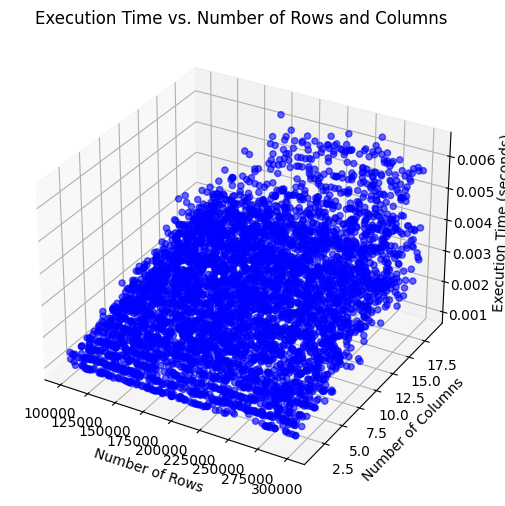

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting toolkit

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with rows on x-axis, columns on y-axis, and execution time on z-axis
ax.scatter(df_train_pd['num_rows'], df_train_pd['num_cols'], df_train_pd['exec_time_sec'], 
           c='b', marker='o', alpha=0.6)

ax.set_xlabel('Number of Rows')
ax.set_ylabel('Number of Columns')
ax.set_zlabel('Execution Time (seconds)')
ax.set_title("Execution Time vs. Number of Rows and Columns")
plt.show()


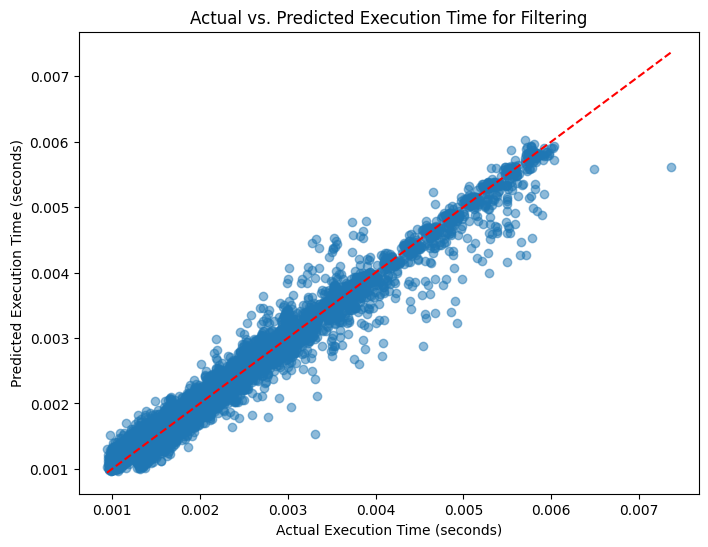

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [1]:
features = {'num_rows': 146050,
 'num_cols': 12,
 'dtype_str': encoder.transform(['int']),
 'nan_ratio': 0.0,
 'target_selectivity':0.31016775077028413}

x_real = pd.DataFrame([features])
predicted_time = model.predict(x_real)
print(predicted_time[0]*1000, "5.47 ms ± 78.3 µs per loop")

NameError: name 'encoder' is not defined

In [19]:
importances = model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print("\nFeature Importances:")
feature_importance_df


Feature Importances:


,feature,importance
1,num_cols,0.410699
4,target_selectivity,0.373044
0,num_rows,0.150736
3,nan_ratio,0.064823
2,dtype_str,0.000698


## GROUPBY


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [1:28:00<00:00,  1.89it/s]



Test Mean Squared Error: 3.188631945600192e-06

Test Root Mean Squared Error: 0.0017856740871727381

Test R2: 0.9766995265925794


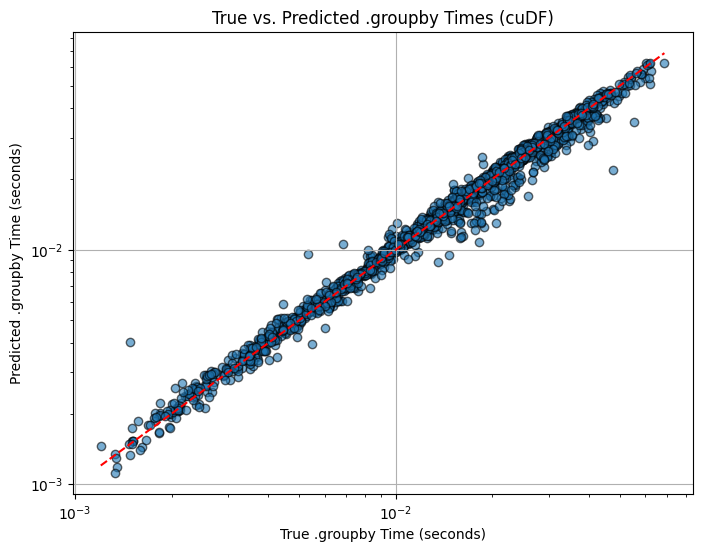

In [22]:
import time
import numpy as np
import cudf
import cupy as cp
import random
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def generate_cudf_dataframe(n_rows, n_cols, group_range):
    """Generate a cuDF DataFrame with random numerical data and categorical groups."""
    group_keys = np.random.choice(range(group_range), size=n_rows)
    
    data = {'group_key': group_keys}
    int_count, float_count = 0, 0

    for i in range(n_cols):
        col_name = f'col{i}'
        if random.choice([True, False]):  # Randomly assign int or float
            data[col_name] = np.random.randint(0, 1000, size=n_rows)
            int_count += 1
        else:
            data[col_name] = np.random.rand(n_rows)
            float_count += 1

    df = cudf.DataFrame(data)

    # Compute group statistics
    group_sizes = df['group_key'].value_counts()
    max_group_size = group_sizes.max()
    n_groups = len(group_sizes)

    return df, int_count, float_count, n_groups, max_group_size

def time_cudf_groupby(n_rows, n_cols, group_range, repetitions=20):
    """Measure execution time of cuDF `groupby` operation."""
    df, int_count, float_count, n_groups, max_group_size = generate_cudf_dataframe(
        n_rows, n_cols, group_range
    )

    aggregation_functions = ['sum', 'mean', 'count']
    chosen_agg = random.choice(aggregation_functions)

    start_event = cp.cuda.Event()
    end_event = cp.cuda.Event()
    
    start_event.record()
    for _ in range(repetitions):
        if chosen_agg == 'sum':
            df.groupby('group_key').sum()
        elif chosen_agg == 'mean':
            df.groupby('group_key').mean(numeric_only=True)
        else:
            df.groupby('group_key').count()
    end_event.record()
    
    end_event.synchronize()
    groupby_time = cp.cuda.get_elapsed_time(start_event, end_event) / (1000 * repetitions)  # Convert to seconds

    features = {
        'n_rows': n_rows,
        'n_cols': n_cols,
        'group_range': group_range,
        'n_groups': n_groups,
        'max_group_size': max_group_size,
        'int_count': int_count,
        'float_count': float_count,
        'agg_function': aggregation_functions.index(chosen_agg)  # Encoded as int
    }

    return features, groupby_time

# Generate dataset
n_samples = 10000
data_rows = []
targets = []

for _ in tqdm.tqdm(range(n_samples)):
    feat, groupby_time = time_cudf_groupby(
        n_rows=random.randint(100000, 300000),
        n_cols=random.randint(1, 100),
        group_range=random.randint(10, 5000),
        repetitions=20
    )
    data_rows.append(feat)
    targets.append(groupby_time)

df_features = cudf.DataFrame(data_rows)
y = np.array(targets)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(df_features.to_pandas(), y, test_size=0.2, random_state=42)

# Train XGBoost Model
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nTest Mean Squared Error:", mse)
print("\nTest Root Mean Squared Error:", rmse)
print("\nTest R2:", r2)

# Plot True vs. Predicted cuDF GroupBy Times (Log Scale)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('True .groupby Time (seconds)')
plt.ylabel('Predicted .groupby Time (seconds)')
plt.title('True vs. Predicted .groupby Times (cuDF)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()


In [44]:
features = {'n_rows': 100750,
 'n_cols': 10,
 'group_range': 69,
 'n_groups': 69,
 'max_group_size': 15890,
 'int_count': 5,
 'float_count': 1,
 'agg_function': 1}

X_real = pd.DataFrame([features])
prediction = model.predict(X_real)
print(prediction[0]*1000,"13.1 ms ± 333 µs per loop")

4.093572963029146 13.1 ms ± 333 µs per loop


In [40]:
importances = model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print("\nFeature Importances:")
feature_importance_df


Feature Importances:


,feature,importance
1,n_cols,0.602497
7,agg_function,0.269914
0,n_rows,0.118902
6,float_count,0.002449
2,group_range,0.002290
4,max_group_size,0.001989
5,int_count,0.001959
3,n_groups,0.000000


In [45]:
import pandas as pd
import numpy as np
import math
import warnings

def create_dataframe_from_features(features):
    """
    Generates a Pandas DataFrame based on specified features, including grouping characteristics.

    Args:
        features (dict): A dictionary containing the DataFrame specifications:
            - 'n_rows' (int): Total number of rows.
            - 'n_cols' (int): Total number of columns.
            - 'int_count' (int): Number of integer columns (excluding group key if used).
            - 'float_count' (int): Number of float columns.
            - 'group_range' (int): The upper bound (exclusive) for potential group IDs.
            - 'n_groups' (int): The exact number of unique group IDs to generate.
            - 'max_group_size' (int): The target maximum size for any single group.
            # 'agg_function' is not directly used for generation but could inform data distribution later.

    Returns:
        pd.DataFrame: The generated Pandas DataFrame.
        dict: A dictionary containing the actual characteristics of the generated DataFrame for verification.
    """

    n_rows = features['n_rows']
    n_cols = features['n_cols']
    int_count = features['int_count']
    float_count = features['float_count']
    group_range = features['group_range']
    n_groups = features['n_groups']
    max_group_size_target = features['max_group_size']

    # Calculate the number of string/object columns needed
    # One column will be dedicated to the grouping key
    n_group_cols = 1
    string_count = n_cols - int_count - float_count - n_group_cols

    if string_count < 0:
        raise ValueError("Sum of int_count, float_count, and 1 group_col exceeds n_cols.")
    if n_groups > group_range:
         raise ValueError("n_groups cannot be greater than group_range.")
    if n_groups <= 0:
         raise ValueError("n_groups must be positive.")
    if n_rows < n_groups:
        warnings.warn("n_rows is less than n_groups, impossible to generate requested number of groups.")
        n_groups = n_rows # Adjust n_groups if fewer rows than groups requested


    print(f"Generating DataFrame with {n_rows:,} rows and {n_cols} columns.")
    print(f"Targeting: {int_count} int, {float_count} float, {string_count} string, 1 group_key column.")
    print(f"Grouping: {n_groups} unique groups from range [0, {group_range}), target max size {max_group_size_target:,}.")

    data = {}
    col_names = []

    # --- Generate Grouping Column ---
    group_col_name = 'group_key'
    col_names.append(group_col_name)

    # 1. Select the actual group IDs we will use
    possible_group_ids = np.arange(group_range)
    if n_groups == group_range:
        actual_group_ids = possible_group_ids
    else:
        # Choose n_groups unique IDs from the possible range
        actual_group_ids = np.random.choice(possible_group_ids, size=n_groups, replace=False)

    # 2. Assign group IDs to rows
    # We aim for n_groups, and try to respect max_group_size.
    # A simple random assignment is often sufficient for generating test data.
    # More complex methods could guarantee max_group_size but add complexity.
    data[group_col_name] = np.random.choice(actual_group_ids, size=n_rows, replace=True)
    print(f"Generated '{group_col_name}'. Verifying group characteristics...")

    # Verify group characteristics immediately
    group_counts = pd.Series(data[group_col_name]).value_counts()
    actual_n_groups = len(group_counts)
    actual_max_group_size = group_counts.max()
    min_group_size = group_counts.min()

    print(f"  Actual unique groups generated: {actual_n_groups} (Target: {n_groups})")
    print(f"  Actual max group size: {actual_max_group_size:,} (Target: <= {max_group_size_target:,})")
    print(f"  Min group size: {min_group_size:,}")

    if actual_n_groups != n_groups:
         warnings.warn(f"Generated {actual_n_groups} groups, but targeted {n_groups}. "
                       "This might happen if n_rows is small relative to n_groups.")
    if actual_max_group_size > max_group_size_target:
         warnings.warn(f"Actual max group size ({actual_max_group_size:,}) exceeded target ({max_group_size_target:,}) "
                       "due to random assignment.")

    # --- Generate Integer Columns ---
    # Use relatively small integers for potential duplicates
    max_int_val = min(n_rows // 10, 50000) # Heuristic for int range
    for i in range(int_count):
        col_name = f'int_col_{i}'
        data[col_name] = np.random.randint(0, max_int_val, size=n_rows)
        col_names.append(col_name)

    # --- Generate Float Columns ---
    for i in range(float_count):
        col_name = f'float_col_{i}'
        data[col_name] = np.random.rand(n_rows) * 1000 # Floats between 0 and 1000
        col_names.append(col_name)

    # --- Generate String Columns ---
    # Use controlled cardinality for strings
    max_str_val = min(n_rows // 20, 10000) # Heuristic for string cardinality
    for i in range(string_count):
        col_name = f'str_col_{i}'
        str_keys = np.random.randint(0, max_str_val, size=n_rows)
        data[col_name] = [f'val_{x}' for x in str_keys]
        col_names.append(col_name)

    # --- Create DataFrame ---
    df = pd.DataFrame(data)

    # Reorder columns to match expected counts if needed (optional)
    # This ensures group_key, ints, floats, strings order if desired
    df = df[col_names]


    # --- Final Verification ---
    actual_features = {
        'n_rows': df.shape[0],
        'n_cols': df.shape[1],
        'int_count': len(df.select_dtypes(include=np.integer).columns),
         # Exclude group_key if it's integer type (it is here)
        'int_count_excluding_group_key': len(df.select_dtypes(include=np.integer).columns.difference([group_col_name])),
        'float_count': len(df.select_dtypes(include=np.floating).columns),
        'string_object_count': len(df.select_dtypes(include=['object', 'string']).columns),
        'group_col_name': group_col_name,
        'group_range': group_range, # The requested range
        'n_groups_actual': actual_n_groups,
        'max_group_size_actual': actual_max_group_size,
        'min_group_size_actual': min_group_size,
        'memory_usage_gb': df.memory_usage(deep=True).sum() / 1e9
    }

    print("-" * 30)
    print("DataFrame Generation Summary:")
    for key, val in actual_features.items():
        if isinstance(val, (int, np.integer)) and val > 1000:
             print(f"  {key}: {val:,}")
        elif isinstance(val, (float, np.floating)):
             print(f"  {key}: {val:.3f}")
        else:
             print(f"  {key}: {val}")
    print("-" * 30)


    return df, actual_features

# --- Example Usage ---
features_spec = {
    'n_rows': 100750,
    'n_cols': 10,
    'group_range': 69, # Means groups can be ID 0 through 68
    'n_groups': 69,    # We want exactly 69 unique groups
    'max_group_size': 15890,
    'int_count': 5,    # 5 dedicated integer columns
    'float_count': 1,  # 1 dedicated float column
    # 'agg_function': 1 # Not used in generation
}

try:
    df_generated, df_actual_features = create_dataframe_from_features(features_spec)
    print("\nGenerated DataFrame Head:")
    print(df_generated.head())
    # print("\nGenerated DataFrame Info:")
    # df_generated.info() # Can uncomment for detailed dtype/memory info

except ValueError as e:
    print(f"Error generating DataFrame: {e}")

Generating DataFrame with 100,750 rows and 10 columns.
Targeting: 5 int, 1 float, 3 string, 1 group_key column.
Grouping: 69 unique groups from range [0, 69), target max size 15,890.
Generated 'group_key'. Verifying group characteristics...
  Actual unique groups generated: 69 (Target: 69)
  Actual max group size: 1,544 (Target: <= 15,890)
  Min group size: 1,335
------------------------------
DataFrame Generation Summary:
  n_rows: 100,750
  n_cols: 10
  int_count: 6
  int_count_excluding_group_key: 5
  float_count: 1
  string_object_count: 3
  group_col_name: group_key
  group_range: 69
  n_groups_actual: 69
  max_group_size_actual: 1,544
  min_group_size_actual: 1,335
  memory_usage_gb: 0.025
------------------------------

Generated DataFrame Head:
   group_key  int_col_0  int_col_1  int_col_2  int_col_3  int_col_4  \
0         33       7701       9667       3872       9052       5162   
1         64       2438         62       1822       4555       3302   
2         16       4005 

In [51]:
%%cudf.pandas.profile
df_generated.groupby('int_col_0').mean(numeric_only=True)

,group_key,int_col_1,int_col_2,int_col_3,int_col_4,float_col_0
int_col_0,,,,,,
0,21.625000,3757.875000,4576.375000,3859.875000,4660.000000,570.532481
1,21.666667,2860.555556,7199.666667,3232.111111,4927.333333,620.378205
2,33.500000,3478.500000,4100.700000,5187.300000,4577.800000,518.053274
3,31.285714,5237.142857,4943.000000,6730.142857,5172.857143,537.203746
4,32.625000,5532.875000,4736.500000,4335.750000,7608.500000,496.225545
...,...,...,...,...,...,...
10070,36.900000,4996.600000,5428.000000,6023.500000,4187.900000,599.342771
10071,33.818182,5549.636364,5887.636364,4705.727273,4468.818182,504.712777
10072,20.714286,3712.285714,5682.285714,4044.714286,4731.857143,549.295950


                                                                                              
                                  Total time elapsed: 0.146 seconds                           
                                0 GPU function calls in 0.000 seconds                         
                                0 CPU function calls in 0.000 seconds                         
                                                                                              
                                                Stats                                         
                                                                                              
┏━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Function ┃ GPU ncalls ┃ GPU cumtime ┃ GPU percall ┃ CPU ncalls ┃ CPU cumtime ┃ CPU percall ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
└──────────┴────────────┴─────────────┴─────────────┴────────────┴─────────────┴─────────────┘

In [ ]:
data = 